# Analyse des survivants du Titanic
**Dataset :** Kaggle Titanic - train.csv (891 passagers, 12 colonnes)  
**Objectif :** Identifier les facteurs déterminants de survie  
**Stack :** Python, Pandas, NumPy, Matplotlib, Seaborn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

print(f"Dataset : {df.shape[0]} passagers, {df.shape[1]} colonnes")
print(f"Taux de survie global : {df['Survived'].mean():.1%}")
print(f"\nValeurs manquantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

## 1. Nettoyage des données
Les valeurs manquantes de `Age` (177/891) sont remplacées par la **médiane** (28 ans), 
plus robuste que la moyenne face aux valeurs extrêmes.  
`Cabin` (687 manquants) est ignorée car trop incomplète pour être exploitable.

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())
print(f"NaN restants dans Age : {df['Age'].isna().sum()}")

NaN restants dans Age : 0


## 2. Recherche du taux de survie par sexe (H/F)
La première analyse porte sur le taux de survie par sexe. 
D'abord car elle permet de diviser la population étudiée en deux parties, mais aussi car elle nous permet de voir si la premiere partie de la règle : "les femmes et les enfants d'abord ", a été respectée. 
On cherchera donc les chances de survie de chaque sexe et on visualisera l'écart par un graphique en barres.
**Résultat : femmes 74%, hommes 19%.**

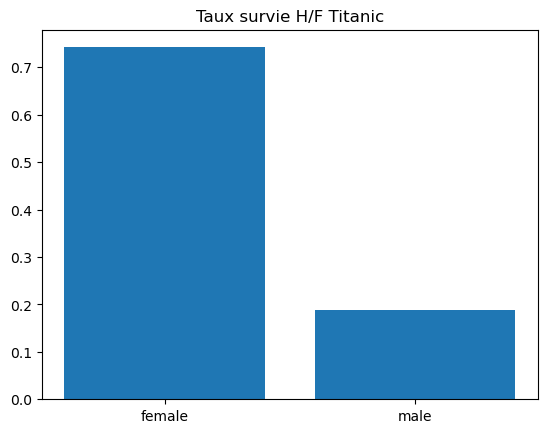

In [13]:
df_survie_sex = df.groupby("Sex")["Survived"].mean()
plt.bar(df_survie_sex.index, df_survie_sex.values)
plt.title("Taux survie H/F Titanic")
plt.show()
plt.close()

## 3. Recherche du taux de survie par classe (1ère, 2ème, 3ème) 
La seconde analyse porte sur le taux de survie par classe. 
L'objectif ici est de voir si la classe occupée par le passager, et donc son revenu, a influencée ou non ses chances de survie.
Pour ce faire on divise la population en fonction des trois classes disponibles : 1ère classe, 2ème classe et 3ème classe.
On cherchera une nouvelle fois les chances de survie de chaque classe et un graphique en barres nous servira également à visualiser l'écart. 
**Résultat : 1ère classe 63%, 2ème classe 47%, 3ème classe 24%.**

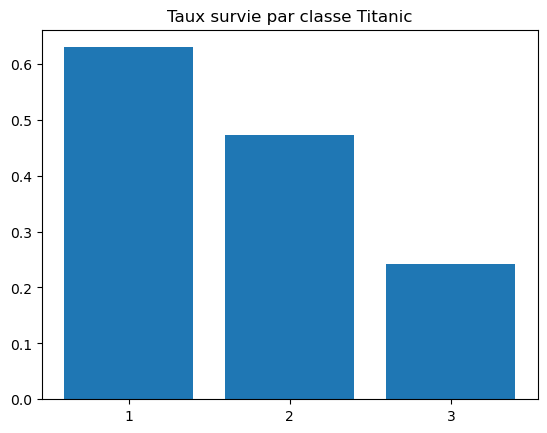

In [15]:
df_survie_classe = df.groupby("Pclass")["Survived"].mean()  
plt.bar(df_survie_classe.index, df_survie_classe.values)
plt.xticks([1, 2, 3])
plt.title("Taux survie par classe Titanic")
plt.show()
plt.close()

## 4. Recherche du taux de survie par âge (Enfant, Adulte, Senior) 
La seconde analyse porte sur le taux de survie par classe. 
L'objectif ici est de voir si l'âge des passager a influencée ou non leurs chances de survie, et d'ainsi voir si la seconde partie de la règle : "les femmes et les enfants d'abord ", a été respectée.
Pour ce faire on divise la population en fonction de leur âge : Enfant 0-18ans, Adulte 18-60, Senior 60-100.
On cherchera une dernière fois les chances de survie de chaque classe d'âge et un graphique en barres nous servira à visualiser l'écart. 
**Résultat : Enfant 50%, Adulte 36%, Senior 23%.**

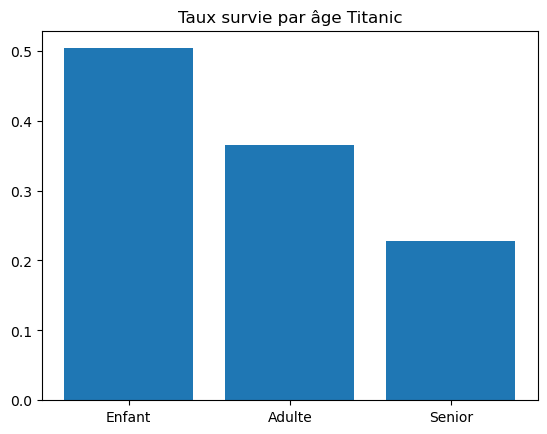

In [17]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 18, 60, 100], labels=["Enfant", "Adulte", "Senior"])
df_survie_age = df.groupby("AgeGroup")["Survived"].mean()
plt.bar(df_survie_age.index, df_survie_age.values)
plt.title("Taux survie par âge Titanic")
plt.show()
plt.close()

## 5. Recherche du taux croisé entre la classe et le sexe 
La dernière analyse porte sur le taux de survie croisé entre la classe et le sexe.  
On cherche quel rôle la classe a-t-elle jouée dans le taux de survie de chaque sexe et inversement afin de deduire quel est le passager type avec le plus de chance de survie, et celui avec le moins de chance de survie. 
**Résultat : Femme en 1ère classe 97%, Homme en 3ème classe 14%%.**

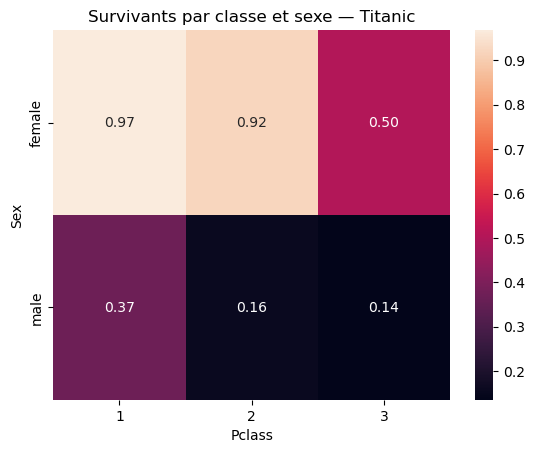

In [21]:
Tableau = df.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean")
sns.heatmap(data=Tableau, annot=True, fmt=".2f")
plt.title("Survivants par classe et sexe — Titanic")
plt.show()
plt.close()